In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DeepAR(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(DeepAR, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear_mu = nn.Linear(hidden_size, 1)
        self.linear_sigma = nn.Linear(hidden_size, 1)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        mu = self.linear_mu(out)
        sigma = F.softplus(self.linear_sigma(out)) + 1e-4
        return mu, sigma, hidden

In [14]:
import torch
from torch.utils.data import Dataset

class GlobalStockDataset(Dataset):
    def __init__(self, df_pivot, seq_len=14, pred_len=14):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.window_size = seq_len + pred_len

        self.data_matrix = torch.tensor(df_pivot.values, dtype=torch.float32)
        self.num_tickers = df_pivot.shape[1]
        self.num_windows = len(df_pivot) - self.window_size + 1

    def __len__(self):
        return self.num_windows * self.num_tickers

    def __getitem__(self, idx):
        window_idx = idx // self.num_tickers
        ticker_idx = idx % self.num_tickers


        window = self.data_matrix[window_idx : window_idx + self.window_size, ticker_idx]


        v = 1.0 + torch.mean(window[:self.seq_len])
        window_scaled = window / v

        age = torch.arange(self.window_size, dtype=torch.float32).unsqueeze(-1) / self.window_size

        x_target = window_scaled[:-1].unsqueeze(-1)
        x = torch.cat([x_target, age[:-1]], dim=-1)
        y = window_scaled[1:]

        return x, y, v

In [17]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
#from model import DeepAR

def loss_fn(mu, sigma, target):
    dist = torch.distributions.LogNormal(mu, sigma)
    return -torch.mean(dist.log_prob(target + 1e-5))

def train_model(df_pivot, epochs=30, batch_size=32, lr=1e-3, seq_len=14, pred_len=14):
    #from dataset import GlobalStockDataset
    dataset = GlobalStockDataset(df_pivot, seq_len=seq_len, pred_len=pred_len)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


    model = DeepAR(input_size=2, hidden_size=64, num_layers=2)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for x, y, v in dataloader:
            optimizer.zero_grad()

            mu, sigma, _ = model(x)
            loss = loss_fn(mu.squeeze(-1), sigma.squeeze(-1), y)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x.size(0)

        print(f"Epoha {epoch+1}/{epochs} | Loss: {epoch_loss / len(dataset):.4f}")

    return model

In [18]:
import torch
import pandas as pd
import numpy as np
#from train import train_model

def load_pivot_data(file_path):
    df = pd.read_csv(file_path)
    df_pivot = df.pivot(index="Date", columns="Ticker", values="Adj Close")
    df_pivot.index = pd.to_datetime(df_pivot.index)
    df_pivot = df_pivot.sort_index()
    df_pivot = df_pivot.ffill().bfill()
    return df_pivot

def predict(model, history, seq_len=14, pred_len=14, num_samples=100):
    model.eval()
    history_tensor = torch.tensor(history, dtype=torch.float32)
    v = 1.0 + torch.mean(history_tensor)

    history_scaled = history_tensor / v
    samples = torch.zeros(num_samples, pred_len)
    window_size = seq_len + pred_len

    with torch.no_grad():
        for i in range(num_samples):
            hidden = None

            age_seq = torch.arange(seq_len, dtype=torch.float32).unsqueeze(-1) / window_size
            x_init = torch.stack([history_scaled, age_seq.squeeze(-1)], dim=-1).unsqueeze(0)
            mu, sigma, hidden = model(x_init)

            curr_mu = mu[:, -1, :]
            curr_sigma = sigma[:, -1, :]

            for t in range(pred_len):
                dist = torch.distributions.LogNormal(curr_mu, curr_sigma)
                sample_scaled = dist.sample()

                samples[i, t] = sample_scaled.item() * v

                next_age = torch.tensor([[[ (seq_len + t) / window_size ]]], dtype=torch.float32)
                next_x = torch.cat([sample_scaled.unsqueeze(1), next_age], dim=-1)

                curr_mu, curr_sigma, hidden = model(next_x, hidden)
                curr_mu = curr_mu.squeeze(0)
                curr_sigma = curr_sigma.squeeze(0)

    return samples

if __name__ == "__main__":
    df_pivot = load_pivot_data("baze_stocks_ts.csv")
    train_pivot = df_pivot.iloc[:-14]

    print("Pokrećem treniranje (Ispravan Globalni DeepAR)...")
    model = train_model(train_pivot, epochs=30, batch_size=32, seq_len=14, pred_len=14)

    # Testiramo na AAPL (indeks 0)
    target_ticker = df_pivot.columns[0]
    test_history = df_pivot[target_ticker].values[-28:-14]
    stvarna_buducnost = df_pivot[target_ticker].values[-14:]

    predictions = predict(model, test_history, seq_len=14, pred_len=14, num_samples=100)

    p50 = torch.median(predictions, dim=0).values
    p10 = torch.quantile(predictions, 0.1, dim=0)
    p90 = torch.quantile(predictions, 0.9, dim=0)

    print(f"\nRezultati za akciju: {target_ticker}")
    print("P10 Predikcija:", np.round(p10.numpy(), 2))
    print("P50 Predikcija:", np.round(p50.numpy(), 2))
    print("P90 Predikcija:", np.round(p90.numpy(), 2))
    print("Stvarne cene:", np.round(stvarna_buducnost, 2))

Pokrećem treniranje (Ispravan Globalni DeepAR)...
Epoha 1/30 | Loss: -2.3089
Epoha 2/30 | Loss: -2.8337
Epoha 3/30 | Loss: -2.8641
Epoha 4/30 | Loss: -2.8804
Epoha 5/30 | Loss: -2.8954
Epoha 6/30 | Loss: -2.9164
Epoha 7/30 | Loss: -2.9275
Epoha 8/30 | Loss: -2.9391
Epoha 9/30 | Loss: -2.9454
Epoha 10/30 | Loss: -2.9503
Epoha 11/30 | Loss: -2.9561
Epoha 12/30 | Loss: -2.9616
Epoha 13/30 | Loss: -2.9643
Epoha 14/30 | Loss: -2.9694
Epoha 15/30 | Loss: -2.9703
Epoha 16/30 | Loss: -2.9745
Epoha 17/30 | Loss: -2.9773
Epoha 18/30 | Loss: -2.9782
Epoha 19/30 | Loss: -2.9810
Epoha 20/30 | Loss: -2.9834
Epoha 21/30 | Loss: -2.9855
Epoha 22/30 | Loss: -2.9885
Epoha 23/30 | Loss: -2.9892
Epoha 24/30 | Loss: -2.9910
Epoha 25/30 | Loss: -2.9932
Epoha 26/30 | Loss: -2.9957
Epoha 27/30 | Loss: -2.9979
Epoha 28/30 | Loss: -3.0001
Epoha 29/30 | Loss: -3.0020
Epoha 30/30 | Loss: -3.0046

Rezultati za akciju: AAPL
P10 Predikcija: [245.85 233.61 222.45 211.06 223.19 219.49 222.42 231.05 231.15 231.39
 228.

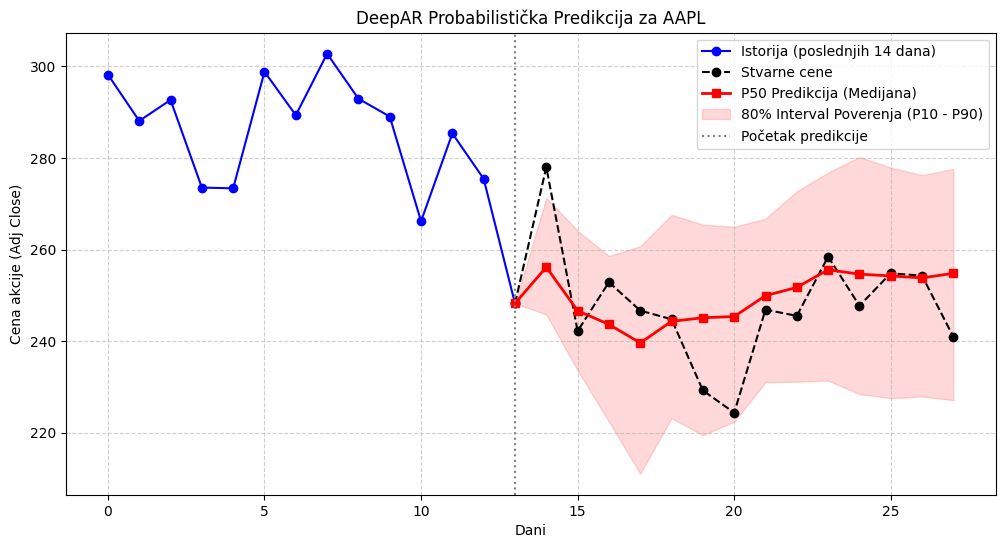

In [19]:
import matplotlib.pyplot as plt

def plot_predictions(test_history, stvarna_buducnost, p10, p50, p90, ticker_name):
    plt.figure(figsize=(12, 6))


    istorija_len = len(test_history)
    pred_len = len(stvarna_buducnost)

    x_istorija = np.arange(istorija_len)
    x_predikcija = np.arange(istorija_len, istorija_len + pred_len)


    plt.plot(x_istorija, test_history, label="Istorija (poslednjih 14 dana)", color="blue", marker="o")


    x_stvarna = np.concatenate(([x_istorija[-1]], x_predikcija))
    y_stvarna = np.concatenate(([test_history[-1]], stvarna_buducnost))
    plt.plot(x_stvarna, y_stvarna, label="Stvarne cene", color="black", linestyle="--", marker="o")


    y_p50 = np.concatenate(([test_history[-1]], p50.numpy() if hasattr(p50, 'numpy') else p50))
    plt.plot(x_stvarna, y_p50, label="P50 Predikcija (Medijana)", color="red", linewidth=2, marker="s")


    y_p10 = np.concatenate(([test_history[-1]], p10.numpy() if hasattr(p10, 'numpy') else p10))
    y_p90 = np.concatenate(([test_history[-1]], p90.numpy() if hasattr(p90, 'numpy') else p90))
    plt.fill_between(x_stvarna, y_p10, y_p90, color="red", alpha=0.15, label="80% Interval Poverenja (P10 - P90)")

    plt.axvline(x=istorija_len - 1, color="gray", linestyle=":", label="Početak predikcije")

    plt.title(f"DeepAR Probabilistička Predikcija za {ticker_name}")
    plt.xlabel("Dani")
    plt.ylabel("Cena akcije (Adj Close)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.show()


plot_predictions(test_history, stvarna_buducnost, p10, p50, p90, target_ticker)

ARIMA MAE: 9.49
DeepAR MAE: 8.13


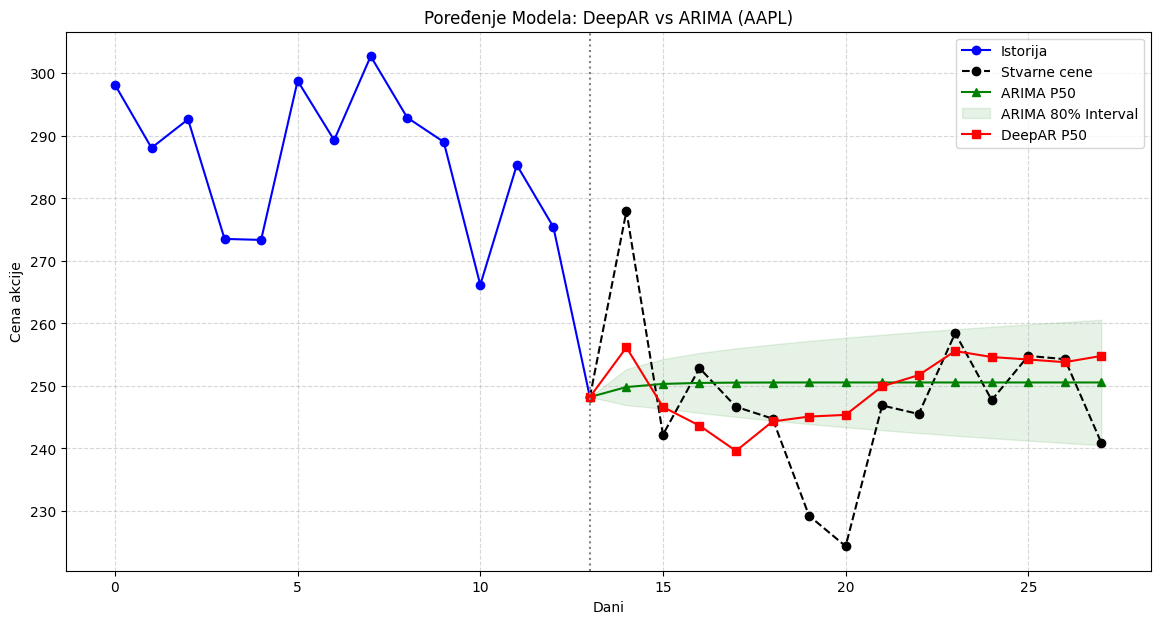

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

def load_pivot_data(file_path):
    df = pd.read_csv(file_path)
    df_pivot = df.pivot(index="Date", columns="Ticker", values="Adj Close")
    df_pivot.index = pd.to_datetime(df_pivot.index)
    df_pivot = df_pivot.sort_index()
    df_pivot = df_pivot.ffill().bfill()
    return df_pivot

def uporedi_modele(file_path, novi_deepar_p50):
    df_pivot = load_pivot_data(file_path)
    target_ticker = df_pivot.columns[0]

    train_series = df_pivot[target_ticker].iloc[:-14].values
    test_history = df_pivot[target_ticker].values[-28:-14]
    stvarna_buducnost = df_pivot[target_ticker].values[-14:]

    model = ARIMA(train_series, order=(1, 1, 1))
    model_fitted = model.fit()

    forecast_res = model_fitted.get_forecast(steps=14)
    arima_p50 = forecast_res.predicted_mean

    ci = forecast_res.conf_int(alpha=0.20)
    arima_p10 = ci[:, 0]
    arima_p90 = ci[:, 1]

    deepar_p50 = np.array(novi_deepar_p50)

    mae_arima = mean_absolute_error(stvarna_buducnost, arima_p50)
    mae_deepar = mean_absolute_error(stvarna_buducnost, deepar_p50)

    print(f"ARIMA MAE: {mae_arima:.2f}")
    print(f"DeepAR MAE: {mae_deepar:.2f}")

    plt.figure(figsize=(14, 7))

    x_istorija = np.arange(14)
    x_predikcija = np.arange(14, 28)
    x_spojeno = np.concatenate(([x_istorija[-1]], x_predikcija))

    plt.plot(x_istorija, test_history, label="Istorija", color="blue", marker="o")

    y_stvarna = np.concatenate(([test_history[-1]], stvarna_buducnost))
    plt.plot(x_spojeno, y_stvarna, label="Stvarne cene", color="black", linestyle="--", marker="o")

    y_arima = np.concatenate(([test_history[-1]], arima_p50))
    plt.plot(x_spojeno, y_arima, label="ARIMA P50", color="green", marker="^")

    y_arima_p10 = np.concatenate(([test_history[-1]], arima_p10))
    y_arima_p90 = np.concatenate(([test_history[-1]], arima_p90))
    plt.fill_between(x_spojeno, y_arima_p10, y_arima_p90, color="green", alpha=0.1, label="ARIMA 80% Interval")

    y_deepar = np.concatenate(([test_history[-1]], deepar_p50))
    plt.plot(x_spojeno, y_deepar, label="DeepAR P50", color="red", marker="s")

    plt.axvline(x=13, color="gray", linestyle=":")
    plt.title(f"Poređenje Modela: DeepAR vs ARIMA ({target_ticker})")
    plt.xlabel("Dani")
    plt.ylabel("Cena akcije")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

if __name__ == "__main__":
    tvoji_novi_deepar_brojevi = []

    uporedi_modele("baze_stocks_ts.csv", p50)